# EDA & Data Quality Report
Notebook kiểm tra chất lượng dữ liệu thô, báo cáo từng bước làm sạch, phát hiện bất thường và chuẩn bị tập train/val/test.  
Mọi thao tác loại bỏ hoặc clip dữ liệu đều kèm **số lượng dòng bị ảnh hưởng và lý do**.


## 1. Setup

In [216]:
import os, re, warnings
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.2f}".format)

# ── Paths ──────────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd().parent.parent
DATA_RAW  = PROJECT_ROOT / "data" / "raw"  / "data_geocoded.csv"
DATA_PROC = PROJECT_ROOT / "data" / "processed"
DATA_PROC.mkdir(parents=True, exist_ok=True)
RESULT_DIR = PROJECT_ROOT / "results"
sys.path.append(str(PROJECT_ROOT))

TEST_SIZE  = 0.2
RANDOM_STATE = 42
IQR_MULT_PRICE = 1.5   # lỏng hơn cho distribution lệch mạnh
IQR_MULT_PHYSICAL = 1.5  # chặt hơn cho feature vật lý

os.makedirs(RESULT_DIR / "data_quality_report", exist_ok=True)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_RAW    :", DATA_RAW)
print("RESULT_PATH  :", RESULT_DIR / "data_quality_report")


PROJECT_ROOT: c:\Users\ADMIN\OneDrive\Desktop\Housing-Market-Prediction\Nhom20
DATA_RAW    : c:\Users\ADMIN\OneDrive\Desktop\Housing-Market-Prediction\Nhom20\data\raw\data_geocoded.csv
RESULT_PATH  : c:\Users\ADMIN\OneDrive\Desktop\Housing-Market-Prediction\Nhom20\results\data_quality_report


## 2. Load dữ liệu thô

In [217]:
df_raw = pd.read_csv(DATA_RAW)
N_RAW = len(df_raw)
print(f"Shape: {df_raw.shape}")
df_raw.head(5)


Shape: (51304, 28)


,Title,Price,Area,Location,Listing ID,Last Updated,Property Type,Width,Length,Bedrooms,Bathrooms,Floors,Position,Direction,Alley Width,Road Type,Description,Latitude,Longitude,VIP Account,Avatar,Agent Role,Agent Name,Agent Listing Count,Province,Property Type Slug,Scraped At,Last Updated Date
0,"🏠 NHÀ 3 TẦNG – TRUNG TÂM PHƯỚC LONG B, THỦ ĐỨC","7,500.00",95.00,"Phường Phước Long,TP. Hồ Chí Minh","1,546,393.00",2 giờ trước,Nhà riêng,5.00,17.00,3.00,3.00,3.00,Đường chính,Bắc,NaN,NaN,"🏠 NHÀ 3 TẦNG – TRUNG TÂM PHƯỚC LONG B, THỦ ĐỨC...",10.82,106.77,False,1,Môi giới,Ngô Quang Tùng,20.00,tp-ho-chi-minh,nha-mat-pho-mat-tien,2025-09-30 18:24:18,30/09/2025 16:24
1,🔥🔥 NHÀ ĐẸP HIỆP BÌNH PHƯỚC – HẺM XE HƠI – KHU ...,"4,500.00",66.00,"đường Hiệp Bình,Phường Hiệp Bình Chánh,Quận Th...","1,528,310.00",2 giờ trước,Nhà riêng,4.00,NaN,2.00,NaN,2.00,Trong hẻm,Nam,NaN,NaN,🔥🔥 NHÀ ĐẸP HIỆP BÌNH PHƯỚC – HẺM XE HƠI – KHU ...,10.86,106.76,False,1,Môi giới,Ngô Quang Tùng,20.00,tp-ho-chi-minh,nha-mat-pho-mat-tien,2025-09-30 18:24:18,30/09/2025 16:24
2,🌟 HXH - NHÀ 3 TẦNG ĐẸP – TRUNG TÂM PHƯỚC LONG ...,"7,500.00",92.00,"Phường Phước Long B,Quận 9,TP. Hồ Chí Minh","1,546,519.00",2 giờ trước,Nhà riêng,5.00,17.00,3.00,3.00,3.00,Trong hẻm,Đông Bắc,NaN,NaN,🌟 HXH - NHÀ 3 TẦNG ĐẸP – TRUNG TÂM PHƯỚC LONG ...,10.84,106.78,False,1,Môi giới,Ngô Quang Tùng,20.00,tp-ho-chi-minh,nha-mat-pho-mat-tien,2025-09-30 18:24:18,30/09/2025 16:24
3,🏡 HÀNG HIẾM LINH CHIỂU – NHÀ 2 TẦNG – VỊ TRÍ V...,"4,750.00",45.00,"đường số 19,Phường Linh Chiểu,Quận Thủ Đức,TP....","1,544,240.00",2 giờ trước,Nhà riêng,4.00,11.50,3.00,NaN,2.00,Đường chính,Đông Nam,NaN,NaN,🏡 HÀNG HIẾM LINH CHIỂU – NHÀ 2 TẦNG – VỊ TRÍ V...,10.86,106.76,False,1,Môi giới,Ngô Quang Tùng,20.00,tp-ho-chi-minh,nha-mat-pho-mat-tien,2025-09-30 18:24:18,30/09/2025 16:24
4,🚗 NHÀ ĐẸP HẺM XE HƠI – VỊ TRÍ VIP LINH TÂY – G...,"4,800.00",82.00,"đường số 9,Phường Linh Tây,Quận Thủ Đức,TP. Hồ...","1,528,291.00",2 giờ trước,Nhà riêng,8.50,NaN,2.00,1.00,1.00,Trong hẻm,Tây,NaN,NaN,🚨 CHỦ CẦN BÁN NHANH – GIẢM 200 TRIỆU 🚨💰 Giá ch...,10.86,106.76,False,1,Môi giới,Ngô Quang Tùng,20.00,tp-ho-chi-minh,nha-mat-pho-mat-tien,2025-09-30 18:24:18,30/09/2025 16:24


In [218]:
# Tổng quan kiểu dữ liệu và missing
summary = pd.DataFrame({
    "dtype":       df_raw.dtypes.astype(str),
    "missing":     df_raw.isna().sum(),
    "missing_%":   (df_raw.isna().mean() * 100).round(2),
    "unique":      df_raw.nunique(dropna=True),
})
summary.sort_values("missing_%", ascending=False)


,dtype,missing,missing_%,unique
Floors,float64,42624,83.08,37
Direction,object,40630,79.19,8
Bathrooms,float64,40540,79.02,44
Alley Width,float64,39051,76.12,139
Road Type,object,37140,72.39,4
Bedrooms,float64,34662,67.56,62
Length,float64,26037,50.75,882
Position,object,21872,42.63,2
Width,float64,17006,33.15,895
Description,object,6211,12.11,41661


## 3. Bảng tracking số dòng qua từng bước làm sạch
Bảng này được cập nhật sau mỗi bước. Chạy lại cell ở cuối section để xem toàn bộ.


In [219]:
# Khởi tạo bảng tracking
tracking = [{"Bước": "0 · Raw data", "Số dòng": N_RAW, "Dòng bị loại": 0, "Lý do": "—"}]

def log_step(label, n_before, n_after, reason):
    tracking.append({
        "Bước": label,
        "Số dòng": n_after,
        "Dòng bị loại": n_before - n_after,
        "Lý do": reason,
    })

def show_tracking():
    t = pd.DataFrame(tracking)
    t["Tích luỹ bị loại"] = N_RAW - t["Số dòng"]
    return t


## 4. Kiểm tra tin đăng trùng lặp / gần trùng
Trùng hoàn toàn: tất cả cột giống nhau.  
Gần trùng: cùng Listing ID hoặc cùng (Price, Area, Location, Property Type) nhưng khác thời điểm đăng.


In [220]:
df = df_raw.copy()

# 4a. Trùng hoàn toàn
n_exact_dup = df.duplicated().sum()
print(f"Trùng hoàn toàn : {n_exact_dup:,} dòng")

# 4b. Trùng Listing ID (cùng tin, crawl nhiều lần)
if "Listing ID" in df.columns:
    n_listingid_dup = df.duplicated(subset=["Listing ID"]).sum()
    print(f"Trùng Listing ID: {n_listingid_dup:,} dòng (giữ lần đầu)")

# 4c. Gần trùng: cùng Price + Area + Location + Property Type
near_dup_cols = [c for c in ["Price","Area","Location","Property Type"] if c in df.columns]
n_near_dup = df.duplicated(subset=near_dup_cols).sum()
print(f"Gần trùng (Price+Area+Location+PropertyType): {n_near_dup:,} dòng")

# Ví dụ vài cặp gần trùng
df[df.duplicated(subset=near_dup_cols, keep=False)].sort_values(near_dup_cols).head(10)[
    near_dup_cols + ["Listing ID","Title","Last Updated"]
]


Trùng hoàn toàn : 0 dòng
Trùng Listing ID: 0 dòng (giữ lần đầu)
Gần trùng (Price+Area+Location+PropertyType): 5,989 dòng


,Price,Area,Location,Property Type,Listing ID,Title,Last Updated
49626,0.00,900.00,"Huyện Bình Chánh,TP. Hồ Chí Minh","Kho, nhà xưởng","1,453,776.00",Bán nhà Kho 900m2 ful thổ cư giá : 25 tỉ còn t...,3 tuần trước
49634,0.00,900.00,"Huyện Bình Chánh,TP. Hồ Chí Minh","Kho, nhà xưởng","1,453,780.00",Bán đất TẶNG nhà kho. mua 2 tặng 1 . 900m2 ful...,3 tuần trước
42003,0.00,NaN,"Huyện Bình Chánh,TP. Hồ Chí Minh",Căn hộ chung cư,"1,454,217.00",SIÊU PHẨM CĂN HỘ HCM 28tr/m² - CONIC BOULEVARD...,3 tuần trước
42004,0.00,NaN,"Huyện Bình Chánh,TP. Hồ Chí Minh",Căn hộ chung cư,"1,454,218.00",CĂN HỘ CONIC BOULEVARD – CHỈ 368 TRIỆU | NHẬN ...,3 tuần trước
19475,290.00,250.00,"Xã Minh Thạnh,TP. Hồ Chí Minh(Mới)",Đất,"1,372,539.00",Bán đất 250m² ngang 5m giá 290 triệu Xã Minh T...,1 tháng trước
19483,290.00,250.00,"Xã Minh Thạnh,TP. Hồ Chí Minh(Mới)",Đất,"1,372,536.00",Bán đất 250m² ngang 5m giá 290 triệu Xã Minh T...,1 tháng trước
19486,290.00,250.00,"Xã Minh Thạnh,TP. Hồ Chí Minh(Mới)",Đất,"1,372,533.00",Bán đất 250m² ngang 5m giá 290 triệu Xã Minh T...,1 tháng trước
20507,420.00,60.00,"Phường Tân Thới Hiệp,TP. Hồ Chí Minh(Mới)",Đất,"1,058,912.00","🔥🔥 Giảm 170tr! Đất vuông 60m², Đ.3m – Hiệp Thà...",1 tháng trước
20511,420.00,60.00,"Phường Tân Thới Hiệp,TP. Hồ Chí Minh(Mới)",Đất,"1,043,206.00","🔥🔥 Giảm 170tr! Đất vuông 60m², Đ.3m – Hiệp Thà...",1 tháng trước
20506,420.00,67.00,"Phường Tân Thới Hiệp,TP. Hồ Chí Minh(Mới)",Đất,"1,058,943.00","🔥🔥 Giảm 170tr! Đất 66m², Đ.3m – Hiệp Thành 17 Q12",1 tháng trước


In [221]:
# Drop theo thứ tự ưu tiên: Listing ID trước, rồi gần trùng
n_before = len(df)

if "Listing ID" in df.columns:
    df = df.drop_duplicates(subset=["Listing ID"]).reset_index(drop=True)
    log_step("1 · Drop trùng Listing ID", n_before, len(df),
             "Cùng Listing ID → cùng tin đăng, crawl nhiều lần")
    n_before = len(df)

df = df.drop_duplicates(subset=near_dup_cols).reset_index(drop=True)
log_step("2 · Drop gần trùng (Price+Area+Location+PropType)", n_before, len(df),
         "Cùng giá/diện tích/vị trí/loại → nhiều khả năng là tin trùng")

print(f"Còn lại: {len(df):,} dòng")


Còn lại: 45,315 dòng


## 5. Lọc giá trị bất hợp lệ (Price & Area)
Không xóa outlier ở đây — chỉ xóa giá trị **không thể tồn tại trong thực tế**.


In [222]:
# Chuyển về numeric
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")
df["Area"]  = pd.to_numeric(df["Area"],  errors="coerce")

checks = {
    "Price is null":    df["Price"].isna().sum(),
    "Price <= 0":       (df["Price"] <= 0).sum(),
    "Price < 100":      (df["Price"] < 100).sum(),    # < 100 triệu — bất thường với HCMC
    "Area is null":     df["Area"].isna().sum(),
    "Area <= 0":        (df["Area"] <= 0).sum(),
    "Area > 10000 m²":  (df["Area"] > 10_000).sum(),  # khả năng cao là đất KCN, không phải nhà ở
}
pd.DataFrame.from_dict(checks, orient="index", columns=["Số dòng"]).rename_axis("Vấn đề")


,Số dòng
Vấn đề,
Price is null,0
Price <= 0,20
Price < 100,63
Area is null,93
Area <= 0,0
Area > 10000 m²,840


In [223]:
n_before = len(df)

# Loại null / <= 0 (không thể dùng được)
mask_invalid = df["Price"].isna() | (df["Price"] <= 0) | df["Area"].isna() | (df["Area"] <= 0)
df = df[~mask_invalid].reset_index(drop=True)
log_step("3 · Loại Price/Area null hoặc <= 0", n_before, len(df),
         "Giá hoặc diện tích null/âm/bằng 0 → không thể dùng để train")

# GHI CHÚ: KHÔNG xóa Price < 100 hay Area > 10000 ở đây.
# Những giá trị này sẽ được kiểm tra thêm ở mục 6 và xử lý bằng clip.
print(f"Còn lại: {len(df):,} dòng")


Còn lại: 45,205 dòng


## 6. Kiểm tra các giá trị bất thường chi tiết

### 6.1 Giá bằng 0 hoặc quá thấp / quá cao


Biểu đồ phân phối Price đã được lưu vào: c:\Users\ADMIN\OneDrive\Desktop\Housing-Market-Prediction\Nhom20\results\data_quality_report\price_distribution.png


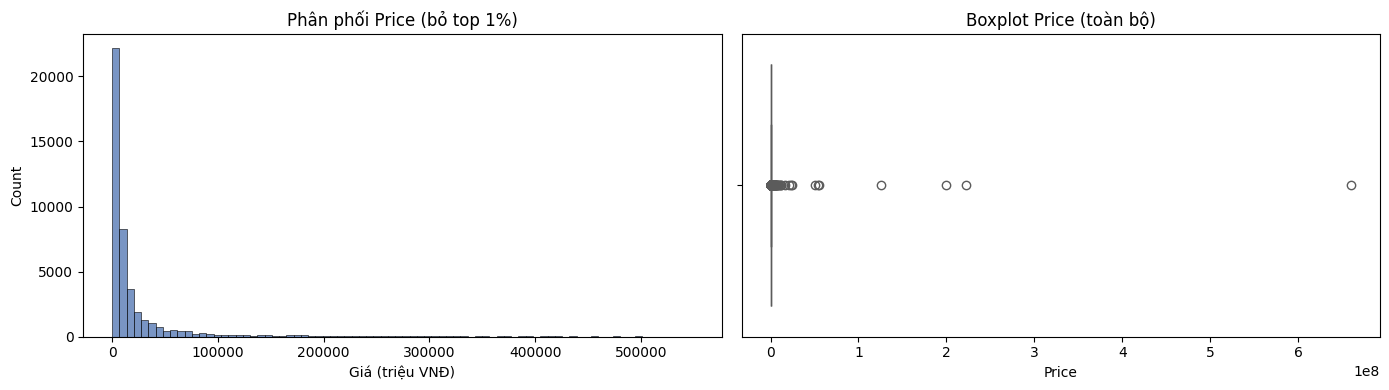

count        45,205.00
mean         72,723.17
std       3,496,212.04
min               0.13
25%           3,300.00
50%           7,000.00
75%          20,000.00
max     660,000,000.00


In [224]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram giá (bỏ top 1% để nhìn rõ phân phối chính)
price_cap = df["Price"].quantile(0.99)
sns.histplot(df.loc[df["Price"] <= price_cap, "Price"], bins=80, ax=axes[0], color="#4C72B0")
axes[0].set_title("Phân phối Price (bỏ top 1%)")
axes[0].set_xlabel("Giá (triệu VNĐ)")

# Boxplot toàn bộ
sns.boxplot(x=df["Price"], ax=axes[1], color="#DD8452")
axes[1].set_title("Boxplot Price (toàn bộ)")
plt.tight_layout()
plt.savefig(RESULT_DIR / "data_quality_report" / "price_distribution.png", dpi=300)
print("Biểu đồ phân phối Price đã được lưu vào:", RESULT_DIR / "data_quality_report" / "price_distribution.png")
plt.show()

# Thống kê cơ bản
print(df["Price"].describe().to_string())


In [225]:
# Ngưỡng cực thấp / cực cao để GHI NHẬN (chưa xóa)
PRICE_LOW_THRESH  = 100    # triệu VNĐ
PRICE_MID_THRESH  = 30_000  # 30 tỷ
PRICE_HIGH_THRESH = 500_000  # 500 tỷ

low_price  = df[df["Price"] < PRICE_LOW_THRESH]
high_price = df[df["Price"] > PRICE_HIGH_THRESH]

print(f"Giá < {PRICE_LOW_THRESH:,} triệu  : {len(low_price):,} dòng")
print(f"Giá > {PRICE_MID_THRESH:,} triệu  : {(df['Price'] > PRICE_MID_THRESH).sum():,} dòng")
print(f"Giá > {PRICE_HIGH_THRESH:,} triệu : {len(high_price):,} dòng")

print("\n--- Mẫu giá thấp bất thường ---")
display(low_price[["Title","Price","Area","Location","Property Type"]].head(8))

print("\n--- Mẫu giá cao bất thường ---")
display(high_price[["Title","Price","Area","Location","Property Type"]].head(8))


Giá < 100 triệu  : 43 dòng
Giá > 30,000 triệu  : 8,626 dòng
Giá > 500,000 triệu : 508 dòng

--- Mẫu giá thấp bất thường ---


,Title,Price,Area,Location,Property Type
2852,"BÁN NHÀ HXH ĐƯỜNG SỐ 11, LINH XUÂN - 66m2 - 3 ...",55.50,66.00,"Đường Tp. Thủ Đức,Phường Linh Xuân,TP. Hồ Chí ...",Nhà riêng
4755,Cần Cho Thuê Nhà Nguyên Nhà Mới Dọn Vào ở Ngay .,13.00,80.00,"Đường Lò Lu,Phường Trường Thạnh,Quận 9,TP. Hồ ...",Nhà riêng
11022,"Bán đất 1128,8m² ngang 27m giá 69 triệu Phường...",69.00,"1,128.00","đường Ngô Chí Quốc,Phường Tam Bình,TP. Hồ Chí ...",Đất
11912,Bán đất 256m² ngang 5m giá 53.14 triệu tại Xã ...,53.14,256.00,"Xã Long Hòa,TP. Hồ Chí Minh(Mới)",Đất
12810,Bán đất 199.6m² 0.02 triệu tại Thị trấn Lai Uy...,60.00,199.60,"Xã Bàu Bàng,TP. Hồ Chí Minh(Mới)",Đất
16095,Bán đất mặt tiền đường 16m khu 5x19 giá 78tr/m²,78.00,95.00,"Xã Nhà Bè,TP. Hồ Chí Minh(Mới)",Đất
19890,"Chủ cần bán gấp lô đất thổ cư 80m2 giá 1,250 t...",0.13,80.00,"Xã Tân Phú Trung,Huyện Củ Chi,TP. Hồ Chí Minh",Đất
22209,Bán đất nền dự án Topia Garden 109m2 Đường Bưn...,60.00,109.00,"Thành phố Thủ Đức,TP. Hồ Chí Minh",Đất



--- Mẫu giá cao bất thường ---


,Title,Price,Area,Location,Property Type
73,Bán nhà 452.2m² giá 900 tỷ Phường Bến Thành,"900,000.00",452.20,"Phường Bến Thành,TP. Hồ Chí Minh(Mới)",Nhà riêng
81,Bán nhà 1400m² giá 3500 tỷ Phường Sài Gòn,"3,500,000.00","1,400.00","Phường Sài Gòn,TP. Hồ Chí Minh(Mới)",Nhà riêng
721,Bán nhà 40.8m² ngang 4.05m giá 5500 tỷ Phường ...,"5,500,000.00",40.80,"Đường Cây Trâm,Phường Thông Tây Hội,TP. Hồ Chí...",Nhà riêng
1307,Bán tòa nhà có 2 Hầm 15 tầng nổi . Mt đường B...,"750,000.00",532.00,"Đường Bến Vân Đồn,Phường Vĩnh Hội,TP. Hồ Chí...",Nhà riêng
3145,Bán nhà 515.9m² ngang 26m giá 1000 tỷ Phường S...,"1,000,000.00",515.90,"Phường Sài Gòn,TP. Hồ Chí Minh(Mới)",Nhà riêng
5286,"Bán nhà 228.1m² ngang 7,8m giá 12000 tỷ Phường...","12,000,000.00",228.10,"Đường Đại lộ 3,Phường Phước Long,TP. Hồ Chí Mi...",Nhà riêng
5334,Bán nhà 88.6m² giá 16000 tỷ tại Phường Tân Thà...,"16,000,000.00",88.60,"Đường Âu Cơ,Phường Phú Thọ Hòa,TP. Hồ Chí Minh...",Nhà riêng
5901,BDS HVL [NC] 92 LÊ VĂN DUYỆT BÌNH THANHH GIÁ TÔTA,"560,000.00","1,100.00","Phường 01,Quận Bình Thạnh,TP. Hồ Chí Minh",Nhà riêng


### 6.2 Diện tích bằng 0 hoặc bất thường

Biểu đồ phân phối Area đã được lưu vào: c:\Users\ADMIN\OneDrive\Desktop\Housing-Market-Prediction\Nhom20\results\data_quality_report\area_distribution.png


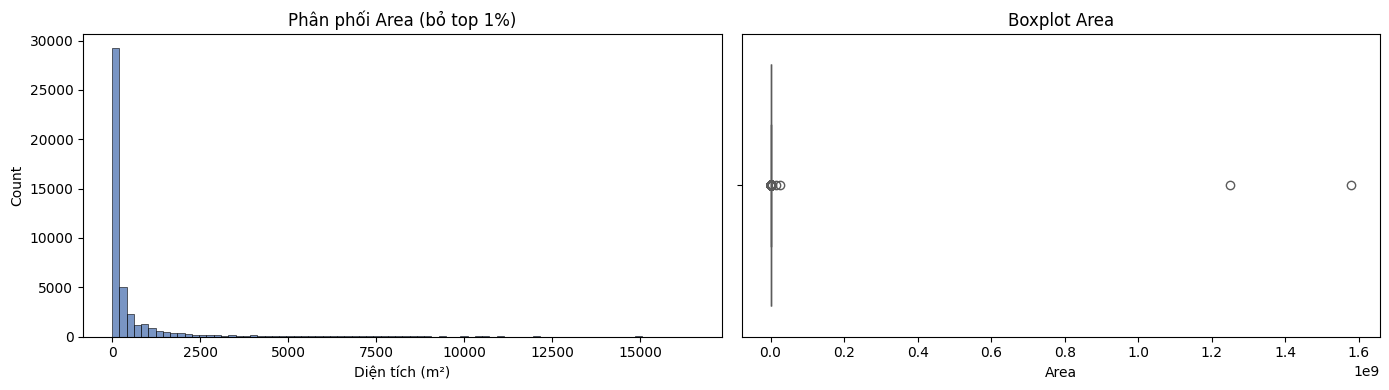

Area > 1,000 m²: 6,440 dòng


,count,min,mean,max
Property Type,,,,
Căn hộ chung cư,53.00,"1,007.00","23,591,203.00","1,250,000,000.00"
"Kho, nhà xưởng",627.00,"1,002.70","5,061.80","145,000.00"
Khách sạn,19.00,"1,215.00","6,035.20","19,173.00"
Nhà riêng,149.00,"1,001.00","4,763.20","152,922.00"
Nhà trọ,18.00,"1,069.00","5,896.50","14,045.00"
Văn phòng,7.00,"1,090.00","2,271.10","7,564.00"
Đất,"5,567.00","1,000.20","300,130.60","1,578,861,169.70"


In [226]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
area_cap = df["Area"].quantile(0.99)
sns.histplot(df.loc[df["Area"] <= area_cap, "Area"], bins=80, ax=axes[0], color="#4C72B0")
axes[0].set_title("Phân phối Area (bỏ top 1%)")
axes[0].set_xlabel("Diện tích (m²)")
sns.boxplot(x=df["Area"], ax=axes[1], color="#DD8452")
axes[1].set_title("Boxplot Area")
plt.tight_layout()
plt.savefig(RESULT_DIR / "data_quality_report" / "area_distribution.png", dpi=300)
print("Biểu đồ phân phối Area đã được lưu vào:", RESULT_DIR / "data_quality_report" / "area_distribution.png")
plt.show()

# Thống kê theo Property Type cho Area lớn
large_area = df[df["Area"] > 1_000]
print(f"Area > 1,000 m²: {len(large_area):,} dòng")
display(large_area.groupby("Property Type")["Area"]
        .describe()[["count","min","mean","max"]].round(1))


### 6.3 Giá/m² bất thường

Biểu đồ phân phối price_per_m2 đã được lưu vào: c:\Users\ADMIN\OneDrive\Desktop\Housing-Market-Prediction\Nhom20\results\data_quality_report\price_per_m2_distribution.png


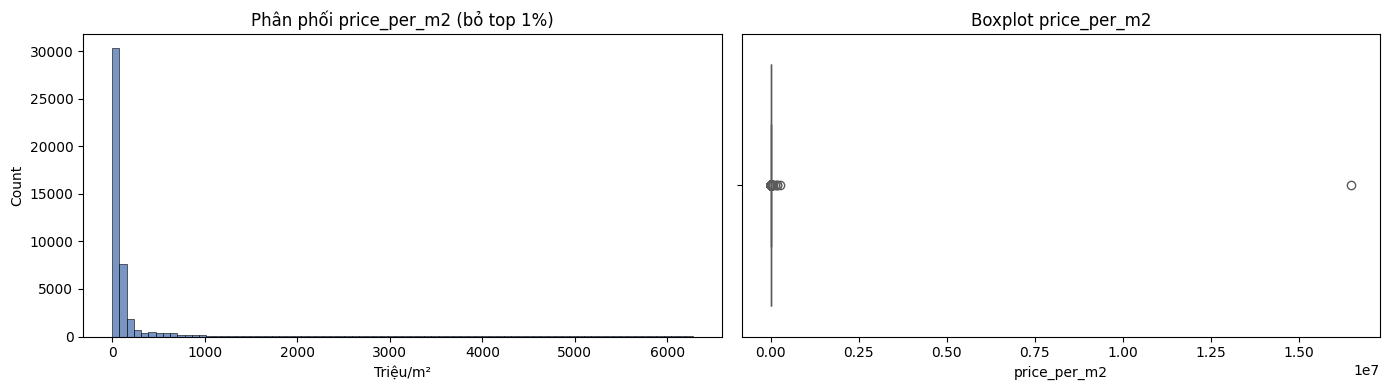

price_per_m2 outlier (IQR ×1.5): 5,505 dòng  (thấp: 0, cao: 5,505)
  Ngưỡng: [-112.9, 230.9] triệu/m²


,Title,Price,Area,price_per_m2,Location,Property Type
12,"Nhà Biệt Thự ✅ Khu Nam Thông Q7, 15x18❤️270m2,...","115,000.00",303.00,379.54,"Phường Bình Trưng,TP. Hồ Chí Minh(Mới)",Nhà riêng
19,Nhà Mặt tiền Liên Phường 30m thông qua nhiều Q...,"25,000.00",100.00,250.00,"Phường Phước Long,TP. Hồ Chí Minh(Mới)",Nhà riêng
32,Bán nhà 130.8m² ngang 6.8m giá 33 tỷ Phường Bì...,"33,000.00",130.80,252.29,"Phường Bình Trưng,TP. Hồ Chí Minh(Mới)",Nhà riêng
43,Bán nhà 84.4m² ngang 5.9m Phường Bình Trưng,"72,000.00",84.40,853.08,"Phường Bình Trưng,TP. Hồ Chí Minh(Mới)",Nhà riêng
47,Bán nhà 358.5m² ngang 10m giá 93 tỷ tại Phường...,"93,000.00",358.50,259.41,"Phường Cát Lái,TP. Hồ Chí Minh(Mới)",Nhà riêng
48,Bán nhà 200m² ngang 10m giá 111 tỷ tại Phường ...,"111,000.00",200.00,555.00,"Phường Cát Lái,TP. Hồ Chí Minh(Mới)",Nhà riêng
56,Bán nhà 160m² ngang 8m giá 45 tỷ tại Phường Th...,"45,000.00",160.00,281.25,"Phường Cát Lái,TP. Hồ Chí Minh(Mới)",Nhà riêng
64,Bán nhà 68.6m² giá 36.5 tỷ Phường Sài Gòn,"36,500.00",68.60,532.07,"Phường Sài Gòn,TP. Hồ Chí Minh(Mới)",Nhà riêng


In [227]:
df["price_per_m2"] = df["Price"] / df["Area"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ppm_cap = df["price_per_m2"].quantile(0.99)
sns.histplot(df.loc[df["price_per_m2"] <= ppm_cap, "price_per_m2"], bins=80,
             ax=axes[0], color="#4C72B0")
axes[0].set_title("Phân phối price_per_m2 (bỏ top 1%)")
axes[0].set_xlabel("Triệu/m²")
sns.boxplot(x=df["price_per_m2"], ax=axes[1], color="#DD8452")
axes[1].set_title("Boxplot price_per_m2")
plt.tight_layout()
plt.savefig(RESULT_DIR / "data_quality_report" / "price_per_m2_distribution.png", dpi=300)
print("Biểu đồ phân phối price_per_m2 đã được lưu vào:", RESULT_DIR / "data_quality_report" / "price_per_m2_distribution.png")
plt.show()

Q1, Q3 = df["price_per_m2"].quantile([0.25, 0.75])
IQR = Q3 - Q1
low_ppm  = df[df["price_per_m2"] < Q1 - IQR_MULT_PRICE * IQR]
high_ppm = df[df["price_per_m2"] > Q3 + IQR_MULT_PRICE * IQR]
print(f"price_per_m2 outlier (IQR ×{IQR_MULT_PRICE}): {len(low_ppm)+len(high_ppm):,} dòng  "
      f"(thấp: {len(low_ppm):,}, cao: {len(high_ppm):,})")
print(f"  Ngưỡng: [{Q1 - IQR_MULT_PRICE*IQR:.1f}, {Q3 + IQR_MULT_PRICE*IQR:.1f}] triệu/m²")
display(high_ppm[["Title","Price","Area","price_per_m2","Location","Property Type"]].head(8))


### 6.4 Số phòng ngủ / số tầng không hợp lý

In [228]:
room_cols = ["Bedrooms", "Bathrooms", "Floors"]
for col in room_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

issues = {}
if "Bedrooms" in df.columns:
    issues["Bedrooms > 20"]  = (df["Bedrooms"] > 20).sum()
    issues["Bedrooms < 0"]   = (df["Bedrooms"] < 0).sum()
if "Bathrooms" in df.columns:
    issues["Bathrooms > 20"] = (df["Bathrooms"] > 20).sum()
    issues["Bathrooms < 0"]  = (df["Bathrooms"] < 0).sum()
if "Floors" in df.columns:
    issues["Floors > 50"]    = (df["Floors"] > 50).sum()
    issues["Floors < 0"]     = (df["Floors"] < 0).sum()

pd.DataFrame.from_dict(issues, orient="index", columns=["Số dòng"]).rename_axis("Vấn đề")


,Số dòng
Vấn đề,
Bedrooms > 20,111
Bedrooms < 0,0
Bathrooms > 20,34
Bathrooms < 0,0
Floors > 50,2
Floors < 0,3


In [229]:
# Mẫu bất thường
if "Bedrooms" in df.columns:
    print("--- Bedrooms > 20 ---")
    display(df[df["Bedrooms"] > 20][
        ["Title","Bedrooms","Bathrooms","Floors","Price","Area","Property Type"]
    ].head(8))


--- Bedrooms > 20 ---


,Title,Bedrooms,Bathrooms,Floors,Price,Area,Property Type
11,"Bán nhà trọ ( 60 phòng) 568.7m² ngang 38,5m gi...",60.00,NaN,1.00,"20,000.00",568.70,Nhà riêng
263,💥CẦN VÁN GẤP DÃY TRỌ 110p 👉GIÁ RẺ,110.00,110.00,1.00,"38,080.00","2,240.00",Nhà riêng
326,Nhà Thuận Giao mặt tiền DT 370m2 (10x37)ngay c...,30.00,NaN,NaN,"8,300.00",370.00,Nhà riêng
422,Bán 3 dãy trọ khoảng 1400m2 đất chính chủ bán,53.00,NaN,NaN,"12,500.00",53.00,Nhà riêng
424,"CHỈ 46tr/m2 HẺM XE HƠI, KHA VẠN CÂN, LINH ĐÔNG...",24.00,NaN,1.00,"19,000.00",412.00,Nhà riêng
437,BÁN BIỆT THỰ MẶT TIỀN KINH DOANH ĐƯỜNG KHỔNG T...,40.00,6.00,5.00,"270,000.00","1,600.00",Nhà riêng
439,Bán nhà fuf thổ 2Mt trước sau. Có 28 căn hộ 75...,34.00,NaN,6.00,"41,000.00",464.00,Nhà riêng
868,"Bán nhà 236,5m² ngang 5m giá 3.5 tỷ tại Xã Tân...",127.00,NaN,"999,999.99","3,500.00",236.00,Nhà riêng


### 6.5 Trích xuất quận / huyện

In [230]:
import sys
from src.preprocessing import extract_district

df["District"] = df["Location"].apply(extract_district)
print("Các District đã trích xuất được:")
display(df["District"].value_counts().to_frame("count"))

Các District đã trích xuất được:


,count
District,
TP. Hồ Chí Minh (Mới),22683
Quận 9,3571
Quận 7,3160
Quận 12,2221
Huyện Củ Chi,1723
Huyện Bình Chánh,1590
Quận Bình Tân,1326
Quận Bình Thạnh,1265
Quận Tân Phú,1116


### 6.6 Dữ liệu bị lệch cột do crawl

In [231]:
# Phát hiện lệch cột: giá trị text xuất hiện trong cột numeric
numeric_check = ["Price", "Area", "Width", "Length", "Bedrooms", "Bathrooms", "Floors"]
shift_issues = {}
for col in numeric_check:
    if col in df.columns:
        non_numeric = pd.to_numeric(df[col], errors="coerce").isna() & df[col].notna()
        shift_issues[col] = non_numeric.sum()

print("Cột numeric chứa giá trị text (có thể bị lệch cột):")
pd.DataFrame.from_dict(shift_issues, orient="index", columns=["Số dòng text"]).rename_axis("Cột")


Cột numeric chứa giá trị text (có thể bị lệch cột):


,Số dòng text
Cột,
Price,0
Area,0
Width,0
Length,0
Bedrooms,0
Bathrooms,0
Floors,0


In [232]:
# Kiểm tra thêm: Width/Length có giá trị vô lý (> 1000m)
for col in ["Width", "Length"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        n_large = (df[col] > 1_000).sum()
        print(f"{col} > 1,000m: {n_large:,} dòng (khả năng đơn vị bị lệch cm → m)")
        if n_large > 0:
            display(df[df[col] > 1_000][["Title", col, "Area", "Price"]].head(5))


Width > 1,000m: 10 dòng (khả năng đơn vị bị lệch cm → m)


,Title,Width,Area,Price
2365,"CẦN TÌM NHÀ ĐẤT CHÍNH CHỦ GÒ VẤP, QUẬN 12","50,000.00","90,000.00","100,000.00"
9190,Bán đất 34000m² ngang 1500m giá 39.9 tỷ Phường...,"1,500.00","34,000.00","39,900.00"
10831,"Bán đất 3935,3m² ngang 4000m giá 1.68 tỷ Xã Hò...","4,000.00","3,935.00","1,680.00"
13394,Đất ngon liền tay,"5,082.00","3,420.00","2,700.00"
13505,Bán đất 1053.5m² 1.2 tỷ tại Xã Minh Hoà Huyện ...,"1,190.00","1,053.50","1,200.00"


Length > 1,000m: 12 dòng (khả năng đơn vị bị lệch cm → m)


,Title,Length,Area,Price
1184,Còn thương lượng,"1,710.00",96.00,"9,000.00"
6239,🏠 NHÀ HXH NGUYỄN ẢNH THỦ HIỆP THÀNH Q12-GẦN NG...,"1,825.00",72.00,"4,300.00"
8869,Bán 7ha có 3.200m thổ cư 2mt đường Lê Trọng Tấ...,"8,000.00","70,000.00","230,000.00"
13394,Đất ngon liền tay,"4,966.00","3,420.00","2,700.00"
13729,Bán 2.6 Ha Đất ở 2Mt có 600 thổ cư Phú Mỹ. Tó...,"10,000.00","26,000.00","73,500.00"


## 7. Chia tập Train / Test
Split trước khi clip/encode để tránh data leakage.


In [233]:
n_before_split = len(df)

# Bỏ dòng thiếu target
df = df.dropna(subset=["Price"]).reset_index(drop=True)
log_step("4 · Drop null Price trước split", n_before_split, len(df),
         "Target null → không dùng được để train/eval")

# Split train/test
df_train, df_test = train_test_split(df, test_size=TEST_SIZE, random_state=RANDOM_STATE)

df_train = df_train.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

print(f"Train : {len(df_train):,} dòng  ({len(df_train)/len(df)*100:.1f}%)")
print(f"Test  : {len(df_test):,} dòng  ({len(df_test)/len(df)*100:.1f}%)")

# Thêm vào tracking
tracking.append({"Bước": "5 · Train split", "Số dòng": len(df_train),
                 "Dòng bị loại": "—", "Lý do": f"{(1-TEST_SIZE)*100:.0f}% của toàn bộ"})
tracking.append({"Bước": "5 · Test split",  "Số dòng": len(df_test),
                 "Dòng bị loại": "—", "Lý do": f"{TEST_SIZE*100:.0f}% của toàn bộ"})

Train : 36,164 dòng  (80.0%)
Test  : 9,041 dòng  (20.0%)


## 8. Remove outlier Price — fit trên train, apply lên test
Dùng phương pháp **IQR × 3.0** fit trên tập train để xác định ngưỡng.  
Các dòng ngoài ngưỡng bị **xóa hẳn** (không clip), ghi vào tracking.  
Ngưỡng từ train được apply lên test (xóa luôn các dòng test nằm ngoài ngưỡng train).

In [234]:
def compute_iqr_bounds(series, multiplier=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - multiplier * iqr, q3 + multiplier * iqr

# ── Remove outlier Price (fit trên train) ─────────────────────────────────────
price_lo, price_hi = compute_iqr_bounds(
    pd.to_numeric(df_train["Price"], errors="coerce").dropna(),
    IQR_MULT_PRICE
)
print(f"=== Remove outlier Price (IQR ×{IQR_MULT_PRICE}) ===")
print(f"  Ngưỡng fit từ train: [{price_lo:,.1f}, {price_hi:,.1f}] triệu VNĐ")

n_before_train = len(df_train)
n_before_test  = len(df_test)

mask_train = (
    pd.to_numeric(df_train["Price"], errors="coerce").between(price_lo, price_hi)
)
mask_test  = (
    pd.to_numeric(df_test["Price"],  errors="coerce").between(price_lo, price_hi)
)

df_train = df_train[mask_train].reset_index(drop=True)
df_test  = df_test[mask_test].reset_index(drop=True)

n_removed_train = n_before_train - len(df_train)
n_removed_test  = n_before_test  - len(df_test)

print(f"  Đã xóa train : {n_removed_train:,} dòng  ({n_removed_train/n_before_train*100:.1f}%)")
print(f"  Đã xóa test  : {n_removed_test:,} dòng  ({n_removed_test/n_before_test*100:.1f}%)")
print(f"  Train còn lại: {len(df_train):,} | Test còn lại: {len(df_test):,}")

log_step(
    "6 · Remove outlier Price (IQR ×1.5)",
    n_before_train,
    len(df_train),
    f"Price ngoài [{price_lo:,.0f}, {price_hi:,.0f}] triệu — fit từ train"
)

# ── Clip feature vật lý (giữ clip vì chỉ hiệu chỉnh giá trị, không xóa dòng) ─
def clip_and_report(train, test, col, multiplier, label=None):
    label = label or col
    s = pd.to_numeric(train[col], errors="coerce").dropna()
    if s.empty:
        return train, test
    lo, hi = compute_iqr_bounds(s, multiplier)

    def do_clip(df):
        return pd.to_numeric(df[col], errors="coerce").clip(lo, hi)

    n_clipped_train = ((pd.to_numeric(train[col], errors="coerce") < lo) |
                       (pd.to_numeric(train[col], errors="coerce") > hi)).sum()
    n_clipped_test  = ((pd.to_numeric(test[col],  errors="coerce") < lo) |
                       (pd.to_numeric(test[col],  errors="coerce") > hi)).sum()

    print(f"  {label:30s} | ngưỡng [{lo:.1f}, {hi:.1f}]"
          f" | clip train={n_clipped_train:,}  test={n_clipped_test:,}")

    train = train.copy(); test = test.copy()
    train[col] = do_clip(train)
    test[col]  = do_clip(test)
    return train, test

print(f"\n=== Clip feature vật lý (IQR ×{IQR_MULT_PHYSICAL}) ===")
physical_cols = ["Area", "Width", "Length", "Floors", "Bedrooms", "Bathrooms", "Alley Width"]
for col in physical_cols:
    if col in df_train.columns:
        df_train, df_test = clip_and_report(df_train, df_test, col, IQR_MULT_PHYSICAL)

print(f"\n=== Clip price_per_m2 (IQR ×{IQR_MULT_PRICE}) ===")
if "price_per_m2" in df_train.columns:
    df_train, df_test = clip_and_report(df_train, df_test, "price_per_m2", IQR_MULT_PRICE)


=== Remove outlier Price (IQR ×1.5) ===
  Ngưỡng fit từ train: [-21,750.0, 45,050.0] triệu VNĐ
  Đã xóa train : 5,143 dòng  (14.2%)
  Đã xóa test  : 1,261 dòng  (13.9%)
  Train còn lại: 31,021 | Test còn lại: 7,780

=== Clip feature vật lý (IQR ×1.5) ===
  Area                           | ngưỡng [-285.8, 684.2] | clip train=4,856  test=1,211
  Width                          | ngưỡng [-2.5, 17.5] | clip train=3,030  test=749
  Length                         | ngưỡng [-6.5, 55.1] | clip train=1,459  test=339
  Floors                         | ngưỡng [-1.0, 7.0] | clip train=41  test=17
  Bedrooms                       | ngưỡng [0.5, 4.5] | clip train=1,187  test=303
  Bathrooms                      | ngưỡng [0.5, 4.5] | clip train=796  test=225
  Alley Width                    | ngưỡng [-5.5, 22.5] | clip train=476  test=120

=== Clip price_per_m2 (IQR ×1.5) ===
  price_per_m2                   | ngưỡng [-86.5, 181.9] | clip train=1,959  test=472


## 9. Phân phối Price trước và sau clip + log-transform

Biểu đồ phân phối Price đã được lưu vào: c:\Users\ADMIN\OneDrive\Desktop\Housing-Market-Prediction\Nhom20\results\data_quality_report\price_distribution_outlier.png


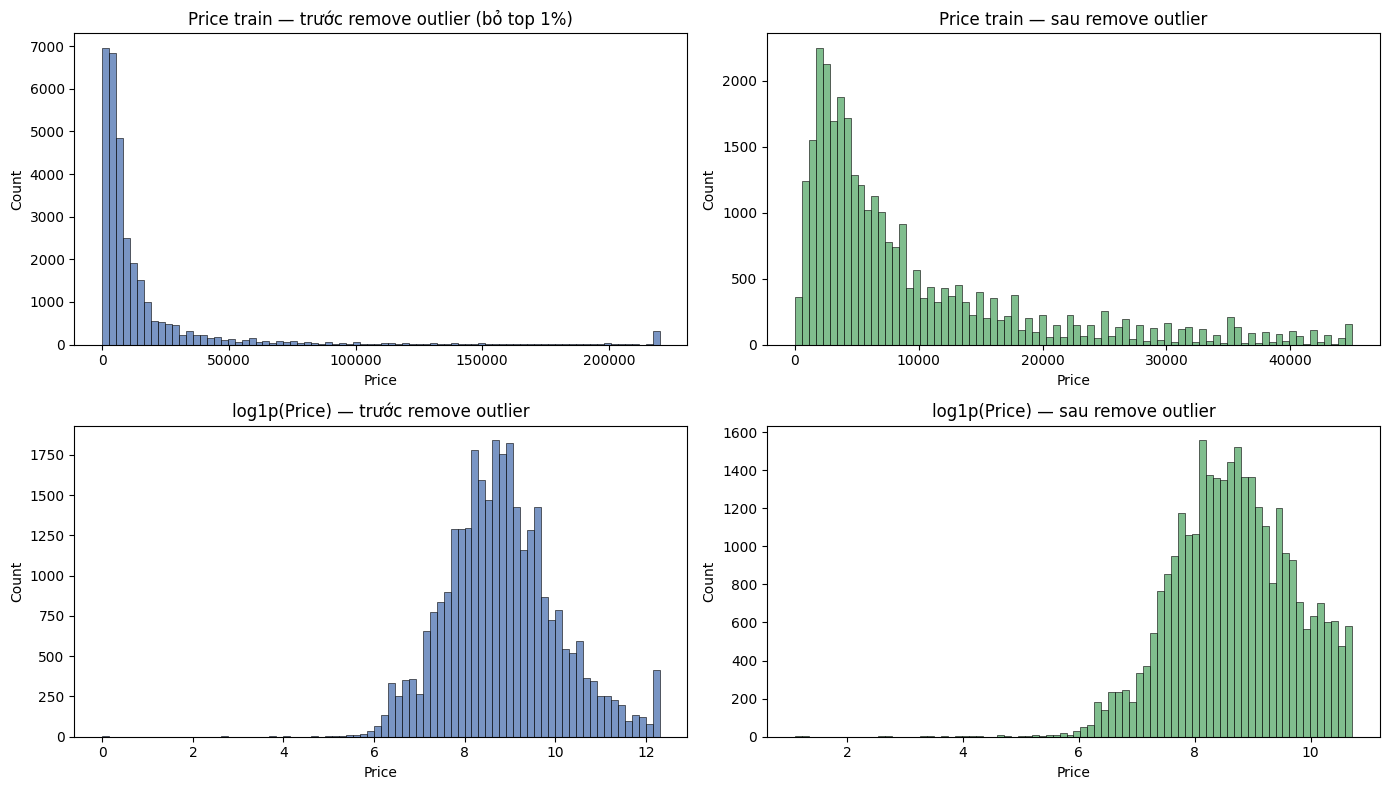

Skewness Price (train, sau remove outlier): 1.765
Skewness log1p(Price) (train)     : -0.275


In [235]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Dữ liệu raw (trước clip) — dùng df_raw lọc cùng index train
raw_price = pd.to_numeric(df_raw.loc[
    df_raw.index.isin(df_train.index) if df_train.index.max() < len(df_raw) else df_raw.index
, "Price"], errors="coerce").dropna()
train_price = df_train["Price"].dropna()

sns.histplot(raw_price.clip(upper=raw_price.quantile(0.99)),
             bins=80, ax=axes[0,0], color="#4C72B0")
axes[0,0].set_title("Price train — trước remove outlier (bỏ top 1%)")

sns.histplot(train_price, bins=80, ax=axes[0,1], color="#55A868")
axes[0,1].set_title("Price train — sau remove outlier")

sns.histplot(np.log1p(raw_price.clip(upper=raw_price.quantile(0.99))),
             bins=80, ax=axes[1,0], color="#4C72B0")
axes[1,0].set_title("log1p(Price) — trước remove outlier")

sns.histplot(np.log1p(train_price), bins=80, ax=axes[1,1], color="#55A868")
axes[1,1].set_title("log1p(Price) — sau remove outlier")

plt.tight_layout()
plt.savefig(RESULT_DIR / "data_quality_report" / "price_distribution_outlier.png", dpi=300)
print("Biểu đồ phân phối Price đã được lưu vào:", RESULT_DIR / "data_quality_report" / "price_distribution_outlier.png")
plt.show()

print("Skewness Price (train, sau remove outlier):", train_price.skew().round(3))
print("Skewness log1p(Price) (train)     :", np.log1p(train_price).skew().round(3))

## 10. Drop columns, Fill median missing values, One-hot encoding

In [236]:
# DROP_COLS = [
#     "Listing ID",
#     "Title",
#     "Description",
#     "Avatar",
#     "Agent Name",
#     "Last Updated",
#     "Scraped At",
#     "Last Updated Date",
#     "Property Type Slug",
#     "Location",
#     "Province",
#     "VIP Account",
#     "Agent Role",
#     "Agent Listing Count",
#     "price_per_m2",
#     "Property Type",
#     "Position",
#     "District",
# ]
w_cols = [
    "Price", "Area", "Bedrooms", "Bathrooms", "Floors", "Alley Width", "Width", "Length", "Latitude", "Longitude", "Property Type", "Position", "Direction", "Road Type", "District"
]
df_train = df_train[w_cols]
df_test  = df_test[w_cols]
print(f"Train columns after drop: {df_train.columns.tolist()}")

Train columns after drop: ['Price', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'Alley Width', 'Width', 'Length', 'Latitude', 'Longitude', 'Property Type', 'Position', 'Direction', 'Road Type', 'District']


In [237]:
NUMERIC_COLS = [
    "Area",
    "Width",
    "Length",
    "Floors",
    "Bedrooms",
    "Bathrooms",
    "Alley Width",
]

# Create missing indicator columns for imputed features
for col in NUMERIC_COLS:

    # Train
    df_train[f"{col}_missing"] = (
        df_train[col]
        .isnull()
        .astype(int)
    )

    # Test
    df_test[f"{col}_missing"] = (
        df_test[col]
        .isnull()
        .astype(int)
    )

# Fill missing values with median of train set
for col in NUMERIC_COLS:

    median_value = df_train[col].median()

    df_train[col] = df_train[col].fillna(
        median_value
    )

    df_test[col] = df_test[col].fillna(
        median_value
    )
    
FIX_COLS = [
    "Floors",
    "Bedrooms",
    "Bathrooms",
]

df_train.loc[
    df_train["Property Type"] == "Đất",
    FIX_COLS
] = 0

df_test.loc[
    df_test["Property Type"] == "Đất",
    FIX_COLS
] = 0

df_train = df_train[df_train["District"] != "Khác"].reset_index(drop=True)
df_test = df_test[df_test["District"] != "Khác"].reset_index(drop=True)

In [238]:
CATEGORICAL_COLS = ["Property Type", "Position", "Direction", "Road Type", "District"]

# Fill missing categorical values with "Unknown"
for col in CATEGORICAL_COLS:
    if col in df_train.columns:
        df_train[col] = df_train[col].fillna("Unknown")
    if col in df_test.columns:
        df_test[col] = df_test[col].fillna("Unknown")

In [239]:
scaling_cols = ["Area", "Bedrooms", "Bathrooms", "Floors", "Alley Width", "Width", "Length"]

from sklearn.preprocessing import StandardScaler
# Standardize numeric features
scaler = StandardScaler()
df_train[scaling_cols] = scaler.fit_transform(df_train[scaling_cols])
df_test[scaling_cols] = scaler.transform(df_test[scaling_cols])
print("Numeric features standardized.")

# Log transform the target variable
df_train["Price"] = np.log1p(df_train["Price"])
df_test["Price"] = np.log1p(df_test["Price"])
print("Target variables logged.")

Numeric features standardized.
Target variables logged.


In [240]:
print("Train shape trước one-hot encoding:", df_train.shape)
print("Test shape trước one-hot encoding:", df_test.shape)

# One-hot encoding cho categorical features
df_train = pd.get_dummies(df_train, columns=CATEGORICAL_COLS, drop_first=True)
df_test  = pd.get_dummies(df_test,  columns=CATEGORICAL_COLS, drop_first=True)

print("Train shape sau one-hot encoding:", df_train.shape)
print("Test shape sau one-hot encoding:", df_test.shape)

df_train = df_train.reindex(sorted(df_train.columns), axis=1)
df_test  = df_test.reindex(sorted(df_test.columns), axis=1)

print("Train columns sau reindex:", df_train.columns.tolist())
print("Test columns sau reindex:", df_test.columns.tolist())

Train shape trước one-hot encoding: (31008, 22)
Test shape trước one-hot encoding: (7780, 22)
Train shape sau one-hot encoding: (31008, 60)
Test shape sau one-hot encoding: (7780, 60)
Train columns sau reindex: ['Alley Width', 'Alley Width_missing', 'Area', 'Area_missing', 'Bathrooms', 'Bathrooms_missing', 'Bedrooms', 'Bedrooms_missing', 'Direction_Nam', 'Direction_Tây', 'Direction_Tây Bắc', 'Direction_Tây Nam', 'Direction_Unknown', 'Direction_Đông', 'Direction_Đông Bắc', 'Direction_Đông Nam', 'District_Huyện Cần Giờ', 'District_Huyện Củ Chi', 'District_Huyện Hóc Môn', 'District_Huyện Nhà Bè', 'District_Quận 1', 'District_Quận 10', 'District_Quận 11', 'District_Quận 12', 'District_Quận 2', 'District_Quận 3', 'District_Quận 4', 'District_Quận 5', 'District_Quận 6', 'District_Quận 7', 'District_Quận 8', 'District_Quận 9', 'District_Quận Bình Thạnh', 'District_Quận Bình Tân', 'District_Quận Gò Vấp', 'District_Quận Phú Nhuận', 'District_Quận Tân Bình', 'District_Quận Tân Phú', 'District_TP

## 11. So sánh thống kê: train / test
Kiểm tra phân phối target không bị lệch giữa các tập.


In [241]:
comparison = pd.DataFrame({
    "train": df_train["Price"].describe(),
    "test":  df_test["Price"].describe(),
}).round(2)
comparison

,train,test
count,"31,008.00","7,780.00"
mean,8.67,8.67
std,1.02,1.01
min,1.10,0.12
25%,7.97,7.99
50%,8.66,8.64
75%,9.39,9.39
max,10.71,10.71


In [242]:
# Kiểm tra district coverage: test có quận nào không có trong train?
if "District" not in df_train.columns and "Location" in df_train.columns:
    try:
        from src.preprocessing import extract_district
        for split_df in [df_train, df_test]:
            split_df["District"] = split_df["Location"].apply(extract_district)
    except ImportError:
        pass

if "District" in df_train.columns:
    train_districts = set(df_train["District"].unique())
    test_new  = set(df_test["District"].unique()) - train_districts
    print(f"Quận có trong test nhưng không trong train : {test_new or 'Không có'}")

## 12. Bảng tổng kết — số dòng qua từng bước làm sạch

In [243]:
show_tracking()

tracking_df = pd.DataFrame(tracking)
display(tracking_df)
tracking_df.to_excel(RESULT_DIR / "data_quality_report" / "data_cleaning_tracking.xlsx", index=False)
print("Bảng tracking đã được lưu vào:", RESULT_DIR / "data_quality_report" / "data_cleaning_tracking.xlsx")

,Bước,Số dòng,Dòng bị loại,Lý do
0,0 · Raw data,51304,0,—
1,1 · Drop trùng Listing ID,51304,0,"Cùng Listing ID → cùng tin đăng, crawl nhiều lần"
2,2 · Drop gần trùng (Price+Area+Location+PropType),45315,5989,Cùng giá/diện tích/vị trí/loại → nhiều khả năn...
3,3 · Loại Price/Area null hoặc <= 0,45205,110,Giá hoặc diện tích null/âm/bằng 0 → không thể ...
4,4 · Drop null Price trước split,45205,0,Target null → không dùng được để train/eval
5,5 · Train split,36164,—,80% của toàn bộ
6,5 · Test split,9041,—,20% của toàn bộ
7,6 · Remove outlier Price (IQR ×1.5),31021,5143,"Price ngoài [-21,750, 45,050] triệu — fit từ t..."


Bảng tracking đã được lưu vào: c:\Users\ADMIN\OneDrive\Desktop\Housing-Market-Prediction\Nhom20\results\data_quality_report\data_cleaning_tracking.xlsx


In [244]:
# Tổng số dòng bị ảnh hưởng bởi clip (không bị xóa)
print("=== Tóm tắt xử lý outlier: Price bị remove, features vật lý bị clip ===")
clip_summary_cols = ["Price", "Area", "Width", "Length",
                     "Floors", "Bedrooms", "Bathrooms", "Alley Width", "price_per_m2"]
rows = []
for col in clip_summary_cols:
    if col in df.columns and col in df_raw.columns:
        s_raw   = pd.to_numeric(df_raw[col], errors="coerce")
        s_clean = pd.to_numeric(df[col], errors="coerce")
        mult = IQR_MULT_PRICE if col in ["Price", "price_per_m2"] else IQR_MULT_PHYSICAL
        lo, hi = compute_iqr_bounds(pd.to_numeric(df[col], errors="coerce").dropna(), mult)
        n_low  = (pd.to_numeric(df[col], errors="coerce") <= lo).sum()
        n_high = (pd.to_numeric(df[col], errors="coerce") >= hi).sum()
        rows.append({"Feature": col, "IQR mult": mult,
                     "Lower": round(lo,2), "Upper": round(hi,2),
                     "Rows clipped low": n_low, "Rows clipped high": n_high})
clip_summary_df = pd.DataFrame(rows)
clip_summary_df.to_excel(RESULT_DIR / "data_quality_report" / "clip_summary.xlsx", index=False)
display(clip_summary_df)
print("Bảng tóm tắt clip đã được lưu vào:", RESULT_DIR / "data_quality_report" / "clip_summary.xlsx")

=== Tóm tắt xử lý outlier: Price bị remove, features vật lý bị clip ===


,Feature,IQR mult,Lower,Upper,Rows clipped low,Rows clipped high
0,Price,1.50,"-21,750.00","45,050.00",0,6404
1,Area,1.50,-389.00,859.00,0,7360
2,Width,1.50,-5.50,22.50,0,3888
3,Length,1.50,-10.00,62.00,0,2101
4,Floors,1.50,-1.00,7.00,3,190
5,Bedrooms,1.50,0.50,4.50,1,1639
6,Bathrooms,1.50,0.50,4.50,1,1103
7,Alley Width,1.50,-3.00,21.00,0,781


Bảng tóm tắt clip đã được lưu vào: c:\Users\ADMIN\OneDrive\Desktop\Housing-Market-Prediction\Nhom20\results\data_quality_report\clip_summary.xlsx


## 13. Lưu tập đã làm sạch

In [245]:
# Drop cột không cần thiết trước khi lưu (giữ price_per_m2 vì hữu ích cho EDA)
drop_for_save = ["price_per_m2"]   # sẽ được tính lại trong feature_engineering pipeline

train_before = len(df_train)
test_before = len(df_test)

df_train = df_train.dropna().reset_index(drop=True)
df_test = df_test.dropna().reset_index(drop=True)

print(f"Train NaN removed: {train_before - len(df_train)}")
print(f"Test NaN removed: {test_before - len(df_test)}")

df_train = df_train.reindex(
    sorted(df_train.columns),
    axis=1
)

df_test = df_test.reindex(
    sorted(df_test.columns),
    axis=1
)

for split_name, split_df in [("train", df_train), ("test", df_test)]:
    out = split_df.copy()
    out.to_csv(DATA_PROC / f"cleaned_{split_name}.csv", index=False)
    print(f"Saved cleaned_{split_name}.csv  {out.shape}")

print("\nDone. Files:", list(DATA_PROC.glob("cleaned_*.csv")))

Train NaN removed: 13
Test NaN removed: 3


Saved cleaned_train.csv  (30995, 60)
Saved cleaned_test.csv  (7777, 60)

Done. Files: [WindowsPath('c:/Users/ADMIN/OneDrive/Desktop/Housing-Market-Prediction/Nhom20/data/processed/cleaned_test.csv'), WindowsPath('c:/Users/ADMIN/OneDrive/Desktop/Housing-Market-Prediction/Nhom20/data/processed/cleaned_train.csv')]
